## 0. Introduction

The aim of this lab is to get familiar with **Neural Networks**. We will be using some code extracts that were implemented on the week 4 Classification I lab and build a Neural Network.

1.   This lab is the third course-work activity **Assignment 1 Part 3: Neural Networks**
2. Assignment 1 is split into 3 parts: Part 1 - Regression (Lab 3), and Part 2 - Classification (Lab 4) and Part 3 - Neural Networks (Lab 6). The three parts need to be submitted together by  **Monday, 11th November 2024, 10:00am**
3. All questions need to be completed and are assessed.
4. For each lab, a report answering the <font color = 'red'>**questions in red**</font> should be included along with the completed Notebook (.ipynb)
5. The report should be a separate file in **pdf format** (so **NOT** *doc, docx, notebook* etc.).
6. Make sure that **any figures or code** you comment on, are **included in the report**.
7. There are three parts of Assignment 1, therefore you should submit a zip file that contains 1 x Notebook and 1 x PDF for each part. In total: 3 x Notebooks and 3 x PDFs in the submission zip. Make sure the file is well identified with your name, student number, assignment number (for instance, Assignment 1), module code.
8. No other means of submission other than the appropriate QM+ link is acceptable at any time (so NO email attachments, etc.)
9. **PLAGIARISM** <ins>is an irreversible non-negotiable failure in the course</ins> (if in doubt of what constitutes plagiarism, ask!).


For this lab, we will be using the [iris dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-dataset).

## 0.1 Intro to Neural Networks

As covered in the lecture notes, Neural Networks (NN) are inspired by biological brains. Each "neuron" does a very simple calculation, however collectively they can do powerful computations.

A simple model neuron is called a Perceptron and is comprised of three components:
1. The weights
2. The input function
3. The activation function

perceptron.png

We can re-imagine the logistic regression unit as a neuron (function) that multiplies the input by the parameters (weights) and squashes the resulting sum through the sigmoid.

A Feed Forward NN will be a connected set of logistic regression units, arranged in layers. Each unit’s output is a non-linear function (e.g., sigmoid, step function) of a linear combination of its inputs.
nn.svg

We will use the sigmoid as an activation function. Add the sigmoid function and `LogisticRegression` class from week 4 lab below.
Change the parameter initialization in `LogisticRegression`, so that a random set of initial weights is used.



<u><font color="red">**Q1.** Why is it important to use a random set of initial weights rather than initializing all weights as zero in a Neural Network? [2 marks] </font></u>


In [1]:
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from sklearn import model_selection
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from IPython import display

import typing
%matplotlib inline

torch.manual_seed(0)

In [2]:
## sigmoid
def sigmoid(z: torch.Tensor) -> torch.Tensor:
  return 1/ (1 + torch.exp(-z))

In [3]:
## logistic regression class
class LogisticRegression(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    #self.weight = nn.Parameter(torch.zeros(1, num_features), requires_grad=False)
    self.weight = nn.Parameter(torch.randn(1, num_features), requires_grad=False)

  def forward(self, x):
    y = 0
    z = x @ self.weight.t() #linear combination of inputs and weights. the forward of the linear regression class lab 3
    y = sigmoid(z) #apply signmoid
    return y

# 1. The XOR problem

Let's revisit the XOR problem.

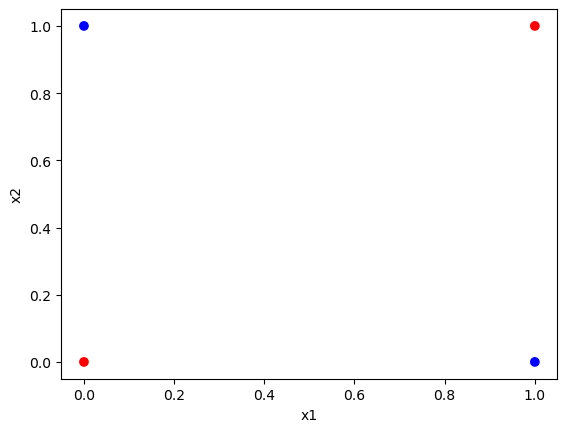

In [4]:
x1 = [0, 0, 1, 1]
x2 = [0, 1, 0, 1]
y = [0, 1, 1, 0]

c_map = ['r', 'b', 'b', 'r']
plt.scatter(x1, x2, c=c_map)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

<u><font color="red"> **Q2.** How does a NN solve the XOR problem? [1 marks]</font></u>


We will implement back-propagation on a Feed Forward network to solve the XOR problem. The nework will have 2 inputs, 2 hidden neurons and one output neuron. The architecture is visualised as follows:

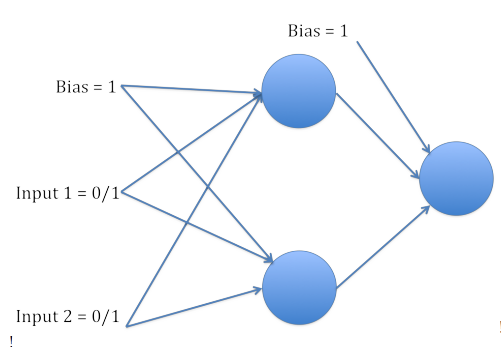

Using `LogisticRegression` and `sigmoid` from week 4 lab, implement the forward pass in the class below. Assume a single sample at a time (i.e. the shape of `x` is `(1, num_features`)). [2 marks]

Hint: Check `ModuleList` [documentation](https://pytorch.org/docs/stable/generated/torch.nn.ModuleList.html).

In [5]:
class NeuralNetwork(nn.Module):
  def __init__(self, num_inputs, num_neurons, num_outputs):
    super().__init__()
    self.hidden_layer = nn.ModuleList([LogisticRegression(num_inputs) for i in range(num_neurons)])
    self.output_layer = nn.ModuleList([LogisticRegression(num_neurons+1) for i in range(num_outputs)]) # +1 for the bias

  def forward(self, x: torch.tensor) -> torch.tensor:
    y_hidden = torch.ones(len(self.hidden_layer) + 1) # +1 for the bias
    ### your code here
    #compute hidden neuron outputs
    for i, neuron in enumerate(self.hidden_layer):
      y_hidden[i] = neuron(x)
    
    #compute output layer outputs
    y_out = torch.zeros(len(self.output_layer))
    for j, neuron in enumerate(self.output_layer):
      y_out[j] = neuron(y_hidden)
      
    return y_out, y_hidden

  def backward_pass(self, x: torch.tensor, y: torch.tensor, lr: float) -> None:
    ### your code here
    if y.dim() == 0:
      y = y.unsqueeze(0)

    y_out, y_hidden = self.forward(x) #run forward first
    
    #step1: compute output layer deltas.
    output_deltas = torch.zeros(len(self.output_layer))
    for k, neuron in enumerate(self.output_layer):
      y_k = y_out[k] #the response of the output neuron
      t_k = y[k] #desired output
      #derivative sigmoid function: $g'(x_{k}) = g(x_{k}) × (1 - g(x_{k}))$
      delta_k = (y_k - t_k) * (y_k * (1 - y_k))
      output_deltas[k] = delta_k
      
    #step 2: propagate this error to the hidden neurons. compute hidden layer deltas.
    hidden_deltas = torch.zeros(len(self.hidden_layer))
    for j, neuron in enumerate(self.hidden_layer):
      y_j = y_hidden[j]
      #sum over k: w_jk * delta_k
      sum_term = 0
      for k, out_neuron in enumerate(self.output_layer):
        w_jk = out_neuron.weight[0, j]  #connection from hidden j to output k
        sum_term += w_jk * output_deltas[k]
      #sigmoid derivate y_j
      delta_j = (y_j * (1 - y_j)) * sum_term
      hidden_deltas[j] = delta_j
      
    #step 3: update output weights
    for k, neuron in enumerate(self.output_layer):
      for j in range(len(y_hidden)):  #include bias neuron
        neuron.weight[0, j] -= lr * output_deltas[k] * y_hidden[j]
    
    #step 4: update hidden weights
    for j, neuron in enumerate(self.hidden_layer):
      for i in range(len(x)):  #includes bias in input
        neuron.weight[0, i] -= lr * hidden_deltas[j] * x[i]
      
    return

In [6]:
# test it works!!
x_test = torch.tensor([0., 0., 1.]) # last value is the bias
y_test = torch.tensor([0.])
model = NeuralNetwork(num_inputs=3, num_neurons=2, num_outputs=1)
print(model(x_test))
print(model)
for name, param in model.named_parameters():
  print(name, param)

print('\nHidden layer weight matrix:')
print(torch.stack(list(model.hidden_layer.parameters())))

(tensor([0.3747]), tensor([0.1017, 0.1980, 1.0000]))
NeuralNetwork(
  (hidden_layer): ModuleList(
    (0-1): 2 x LogisticRegression()
  )
  (output_layer): ModuleList(
    (0): LogisticRegression()
  )
)
hidden_layer.0.weight Parameter containing:
tensor([[ 1.5410, -0.2934, -2.1788]])
hidden_layer.1.weight Parameter containing:
tensor([[ 0.5684, -1.0845, -1.3986]])
output_layer.0.weight Parameter containing:
tensor([[ 0.4033,  0.8380, -0.7193]])

Hidden layer weight matrix:
tensor([[[ 1.5410, -0.2934, -2.1788]],

        [[ 0.5684, -1.0845, -1.3986]]])


In the `NeuralNetwork` class above, fill in the `backward_pass()` method.

The implementation should support outputs of any size. To implement the backward pass, follow the steps below:



*   **Step 1:** For each output, $k$, calculate the partial derivative: $\delta_{k} = (y_{k}-t_{k}) \times g'(x_{k})$ \\
where $y_{k}$ is the response of the output neuron and $t_{k}$ is the desired output (target). The derivative of the sigmoid function $g'(x_{k})$ is defined as $g'(x_{k}) = g(x_{k}) × (1 - g(x_{k}))$ [1 marks]
*  **Step 2:** We now need to propagate this error to the hidden neurons. To accomplish this remember that: $$
 \delta_{j} = g^\prime(x_{j}) \sum_{k} w_{jk} \delta_{k}
$$  where $\delta_{j}$ is the error on the j-th hidden neuron,$x_{j}$ is the value of the hidden neuron (before it has been passed through the sigmoid function), $g^\prime$ is the derivative of the sigmoid function, $\delta_{k}$ is the error from the output neuron calculated in step 1, and $w_{jk}$ is the weight from the hidden neuron $j$ to the output neuron $k$. [1 marks]

* **Step 3:** We now need to update the output weights, i.e. the connections from the hidden neurons to the output neurons. This is accomplished using the formula: $$
 w_{jk} = w_{jk} - \eta \delta_{k} \alpha_{j}
$$ where $w_{jk}$ is the weight connecting the j-th hidden neuron to the k-th output neuron. $\alpha_{j}$ is the activity of the j-th hidden neuron (after it has been transformed by the sigmoid function), $\delta_{k}$ is the error from the output neuron stored in output\_deltas and $\eta$ is the learning rate [1 mark]

* **Step 4:**  Finally we need to update the hidden weights, i.e. the connections from the hidden neurons to the inputs. Here, again we use this equation $$
 w_{ij} = w_{ij} - \eta \delta_{j} x_{i}
$$ where $w_{ij}$ is the weight connecting the i-th input to the j-th hidden neuron. $x_{i}$ is the i-th input, $\delta_{j}$ is the backpropagated error (i.e., hidden deltas) from the j-th hidden neuron and $\eta$ is the learning rate. [1 mark]



In [7]:
# test it works
model.backward_pass(x_test, y_test, 1)

Now modify the code below to train a model on the XOR problem. Make sure to use an appropriate lr and number of iterations. Use the BCE method from week 4 to visualize cost. [1 mark]

torch.Size([4, 3])


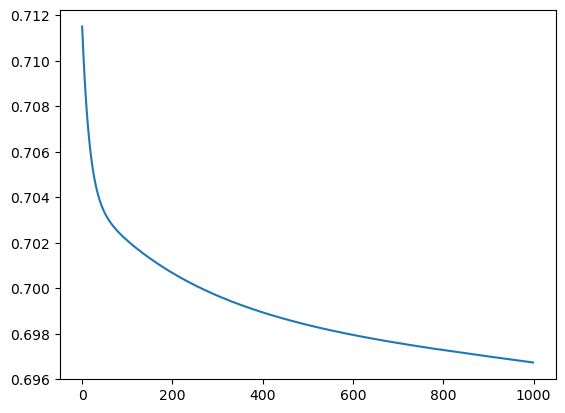

tensor([0., 1., 1., 0.]) tensor([0.4954, 0.5042, 0.4984, 0.5062])


In [8]:
def bce(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
  ### your code here
  #take care of log(0) as its undefined
  epsilon = 1e-7
  y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
  #compute binary cross entropy loss
  bce_loss = - (y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
  bce_loss = bce_loss.mean()
  return bce_loss

#xor data
x1 = torch.tensor([0., 0., 1., 1.])
x2 = torch.tensor([0., 1., 0., 1.])
bias = torch.ones_like(x1)
x = torch.stack([x1, x2, bias]).permute(1, 0)
print(x.shape)
y = torch.tensor([0., 1., 1., 0.])

lr = 0.1 #lr 0.5 bad, lr=1 bad, lr=0.001 bad, lr=0.1 good
iterations = 1000 #instead of 10 do 1000
model = NeuralNetwork(num_inputs=3, num_neurons=2, num_outputs=1)

errors = list()
for ep in range(iterations):
  error = 0
  for i in range(x.shape[0]):
    y_pred, _ = model(x[i]) #modified as nn forward returns y_out and y_hidden
    error += bce(y[i], y_pred)
    model.backward_pass(x[i], y[i], lr)
  errors.append(error/x.shape[0])

plt.plot(list(range(iterations)), errors)
plt.show()

y_pred = torch.zeros_like(y)
for i in range(x.shape[0]): #changed to shape[0] instead of [1]
  y_pred[i], _ = model(x[i]) #modified as nn forward returns y_out and y_hidden
print(y, y_pred)

# 2. Iris Dataset
We will now use pytorch built-in methods to create an MLP classifier for the iris dataset.

In [9]:
iris = datasets.load_iris(as_frame=True)
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Split the data to train and test sets (make sure the same random seed is used as previously) and normalize using the method from week 4. We will use all attributes in this lab. [2 marks]

In [ ]:
### your code here
def norm_set(x: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor) -> torch.tensor:
  z = (x - mu) / sigma #the formula for z-score normalization
  return z

##from lab 4:
#split data to train and test sets
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    iris.data,
    iris.target,
    test_size=0.2,
    random_state=42
    )

x_train = torch.from_numpy(X_train.values).float()
x_test = torch.from_numpy(X_test.values).float()

y_train = torch.from_numpy(y_train.values).long()
y_test = torch.from_numpy(y_test.values).long()

# calculate mean and std from training set
mu = x_train.mean(dim=0)
sigma = x_train.std(dim=0)

# normalize both training and test sets
x_train_norm = norm_set(x_train, mu, sigma)
x_test_norm = norm_set(x_test, mu, sigma)

Using pytorch built in methods (and using the training loop from week 4 as guideline for the train loop), build an MLP with one hidden layer. Train the network multiple times for the following number of hidden neurons `{1, 2, 4, 8, 16, 32}`.

<u><font color="red"> **Q3.** Explain the performance of the different networks on the training and test sets. How does it compare to the logistic regression example? Make sure that the data you are refering to is clearly presented and appropriately labeled in the report. [8 marks]</font></u>

In [11]:
### your code here. 
def build_mlp(num_inputs, num_hidden, num_outputs):
    model = nn.Sequential(
        nn.Linear(num_inputs, num_hidden),
        nn.Sigmoid(), #activation function
        nn.Linear(num_hidden, num_outputs)
    )
    return model

#TRAIN SIMILAR TO LAB 4!!
def train(model, x_train, y_train, x_test, y_test, lr=0.1, epochs=1000):
    optimiser = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_costs= []
    test_costs = []

    for epoch in range(epochs):
        model.train()
        optimiser.zero_grad()
        pred = model(x_train)
        loss = criterion(pred, y_train)
        train_costs.append(loss.item())
        loss.backward()
        optimiser.step()
        model.eval()
        with torch.no_grad():
            test_pred = model(x_test)
            test_loss = criterion(test_pred, y_test)
            test_costs.append(test_loss.item())

    #plot
    plt.figure()
    plt.plot(train_costs, label="Train loss")
    plt.plot(test_costs, label="Test loss")
    plt.legend()
    plt.title("Training vs Test Loss")
    plt.show()

    print(f"Final train loss: {train_costs[-1]:.4f}")
    print(f"Final test loss: {test_costs[-1]:.4f}")


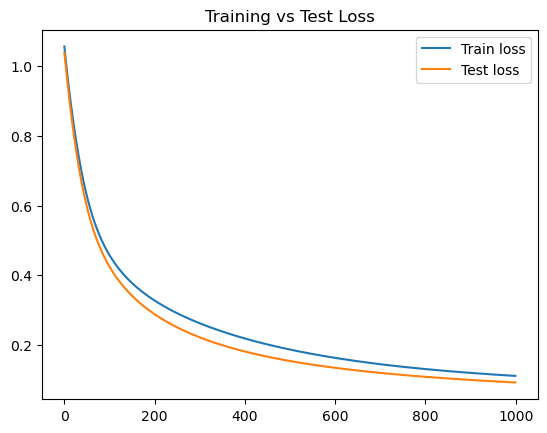

Final train loss: 0.1111
Final test loss: 0.0922


In [12]:
#MAIN

input_dim = x_train_norm.shape[1]
output_dim = 3 #three classes setosa, versicolor, virginica
#change hidden neurons: 1, 2, 4, 8, 16, 32
hidden_neurons = 32

model = build_mlp(input_dim, hidden_neurons, output_dim)
train(model, x_train_norm, y_train, x_test_norm, y_test, lr=0.1, epochs=1000)